# Experiment 7.2 — Two-layer multi-τ SNN training and persistence study

Aggregate-only notebook. Heavy training, per-seed diagnostics, probes, rasters, and checkpoint selection are performed by the Slurm workers and dependency finalizer. This notebook reads only method-level summary CSVs.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd()
if not (ROOT / 'notebooks').exists(): ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_7_2_two_layer_tau_training' / 'two_layer_tau_training_v1'
architectures = pd.read_csv(ART / 'architecture_table.csv')
performance = pd.read_csv(ART / 'performance_summary.csv')
dynamics = pd.read_csv(ART / 'dynamics_summary.csv')
deltas = pd.read_csv(ART / 'paired_deltas.csv')
calibration = pd.read_csv(ART / 'calibration_summary.csv')
ARCH_ORDER = ['234x234','34x234','34x34','34x345','34x45','4x4','5x5']
architectures

,architecture,L1_shifts,L2_shifts,L1_tau_ms,L2_tau_ms
0,234x234,2-3-4,2-3-4,54.3/117.0/242.1,54.3/117.0/242.1
1,34x234,3-4,2-3-4,117.0/242.1,54.3/117.0/242.1
2,34x34,3-4,3-4,117.0/242.1,117.0/242.1
3,34x345,3-4,3-4-5,117.0/242.1,117.0/242.1/492.1
4,34x45,3-4,4-5,117.0/242.1,242.1/492.1
5,4x4,4,4,242.1,242.1
6,5x5,5,5,492.1,492.1


## Formal deployment comparison

`local_tsce` uses frozen L2 → Fixed250 → newly fitted LogisticRegression. `e2e_wc` uses output-LIF valid-length WholeCount. Error bars are mean ± SD across the three paired seeds.

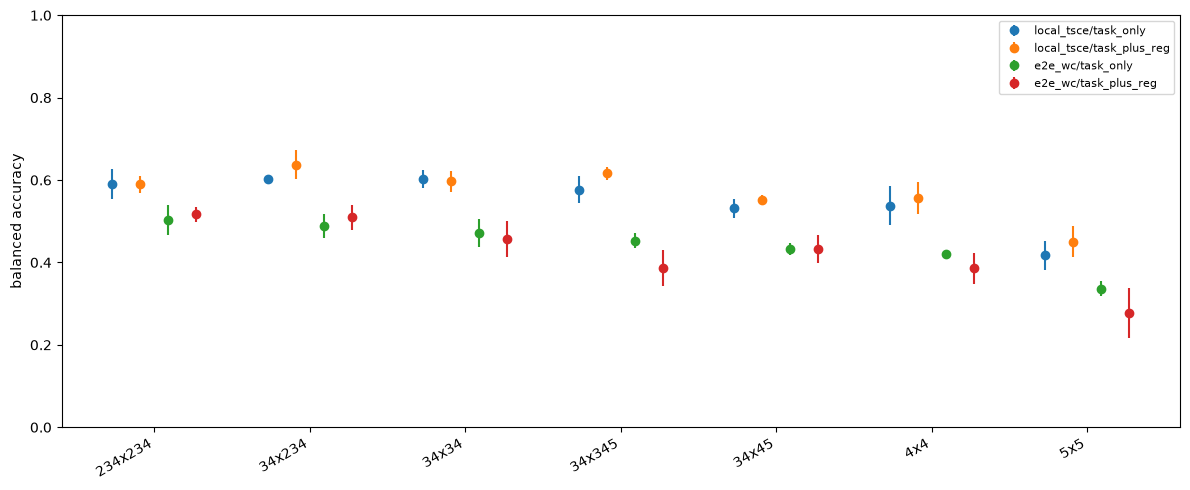

In [2]:
deploy = performance[(performance.split == 'test') & (((performance.training_family == 'local_tsce') & (performance.source == 'l2_fixed250')) | ((performance.training_family == 'e2e_wc') & (performance.source == 'e2e_wholecount')))].copy()
def deployment_plot(metric):
    fig, ax = plt.subplots(figsize=(12,5)); x = np.arange(len(ARCH_ORDER), dtype=float)
    combos = [('local_tsce','task_only'),('local_tsce','task_plus_reg'),('e2e_wc','task_only'),('e2e_wc','task_plus_reg')]
    for off,(family,reg) in zip(np.linspace(-.27,.27,len(combos)), combos):
        means=[]; stds=[]
        for arch in ARCH_ORDER:
            row=deploy[(deploy.architecture==arch)&(deploy.training_family==family)&(deploy.regularization==reg)]
            means.append(np.nan if row.empty else row.iloc[0][f'{metric}_mean']); stds.append(0 if row.empty else row.iloc[0][f'{metric}_std'])
        ax.errorbar(x+off,means,yerr=stds,marker='o',linestyle='none',label=f'{family}/{reg}')
    ax.set_xticks(x,ARCH_ORDER,rotation=30,ha='right'); ax.set_ylim(0,1); ax.set_ylabel(metric.replace('_',' ')); ax.legend(fontsize=8); fig.tight_layout(); return fig
deployment_plot('balanced_accuracy');

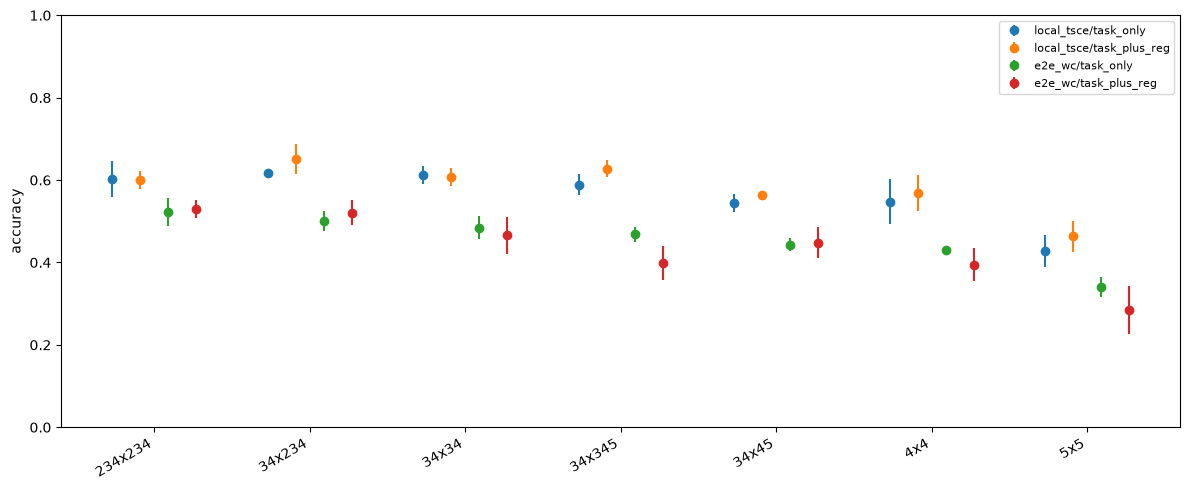

In [3]:
deployment_plot('accuracy');

## E2E information-location probes

The E2E network is frozen before all probes. Compare L2 Fixed250, pre-output evidence Fixed250, post-output spike Fixed250, and formal WholeCount to locate where information is lost.

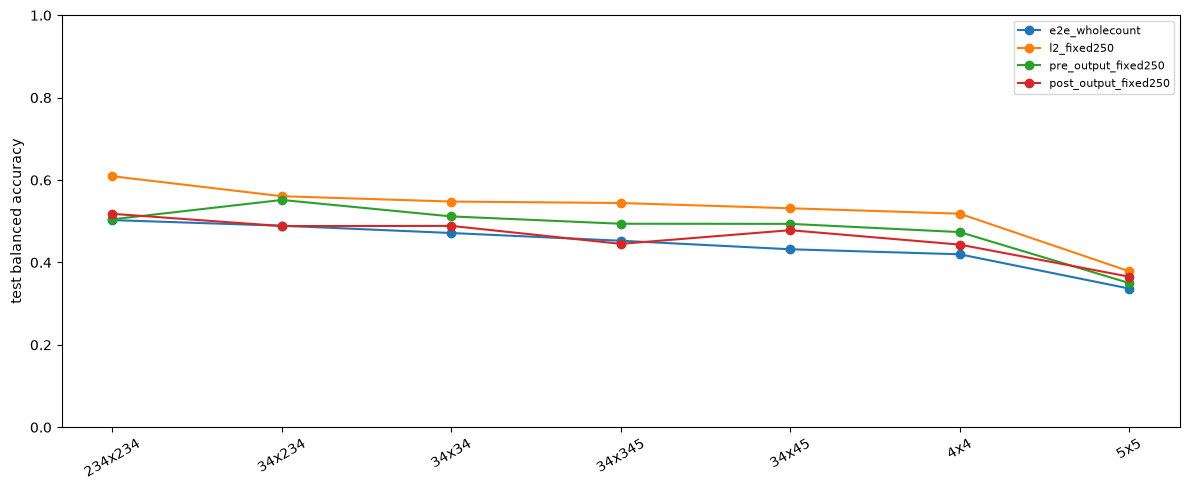

In [4]:
p = performance[(performance.split=='test') & (performance.training_family=='e2e_wc') & performance.source.isin(['e2e_wholecount','l2_fixed250','pre_output_fixed250','post_output_fixed250']) & (performance.regularization=='task_only')]
fig,ax=plt.subplots(figsize=(12,5))
for source in ['e2e_wholecount','l2_fixed250','pre_output_fixed250','post_output_fixed250']:
    vals=[]
    for arch in ARCH_ORDER:
        row=p[(p.architecture==arch)&(p.source==source)]
        vals.append(np.nan if row.empty else row.iloc[0].balanced_accuracy_mean)
    ax.plot(ARCH_ORDER,vals,marker='o',label=source)
ax.set_ylim(0,1); ax.set_ylabel('test balanced accuracy'); ax.tick_params(axis='x',rotation=30); ax.legend(fontsize=8); fig.tight_layout();

## Paired deltas
The finalizer computes seed-paired differences before averaging; these are preferred over subtracting independently aggregated means.

In [5]:
deltas[deltas.metric == 'balanced_accuracy']

,contrast,architecture,training_family,source,regularization,metric,n,delta_mean,delta_std
1,l2_probe_minus_e2e,234x234,e2e_wc,l2_fixed250-e2e_wholecount,task_only,balanced_accuracy,3,0.106472,0.038648
4,l2_probe_minus_e2e,234x234,e2e_wc,l2_fixed250-e2e_wholecount,task_plus_reg,balanced_accuracy,3,0.082223,0.034923
7,l2_probe_minus_e2e,34x234,e2e_wc,l2_fixed250-e2e_wholecount,task_only,balanced_accuracy,3,0.071609,0.009377
10,l2_probe_minus_e2e,34x234,e2e_wc,l2_fixed250-e2e_wholecount,task_plus_reg,balanced_accuracy,3,0.075735,0.045984
13,l2_probe_minus_e2e,34x34,e2e_wc,l2_fixed250-e2e_wholecount,task_only,balanced_accuracy,3,0.076390,0.043520
...,...,...,...,...,...,...,...,...,...
238,reg_minus_task_only,5x5,e2e_wc,l2_fixed250,NaN,balanced_accuracy,3,0.007503,0.047211
241,reg_minus_task_only,5x5,e2e_wc,post_output_fixed250,NaN,balanced_accuracy,3,-0.078829,0.015500
244,reg_minus_task_only,5x5,e2e_wc,pre_output_fixed250,NaN,balanced_accuracy,3,-0.021848,0.020215
247,reg_minus_task_only,5x5,local_tsce,l2_fixed250,NaN,balanced_accuracy,3,0.032829,0.071830


## Shift-resolved hidden dynamics
These statistics are computed over the complete test set and resolved by hidden layer and shift group.

In [6]:
cols=['architecture','training_family','regularization','layer','shift','n','valid_spikes_per_neuron_second_mean','p32_violation_fraction_mean','p84_violation_fraction_mean','mean_max_run_length_mean']
dynamics[[c for c in cols if c in dynamics.columns]].head(50)

,architecture,training_family,regularization,layer,shift,n,valid_spikes_per_neuron_second_mean,p32_violation_fraction_mean,p84_violation_fraction_mean,mean_max_run_length_mean
0,234x234,e2e_wc,task_only,L1,2,3,0.150744,0.000028,0.000028,0.121536
1,234x234,e2e_wc,task_only,L1,3,3,0.983330,0.000722,0.001886,0.442498
2,234x234,e2e_wc,task_only,L1,4,3,5.093040,0.023722,0.047028,2.176886
3,234x234,e2e_wc,task_only,L2,2,3,7.228608,0.059991,0.089409,4.857863
4,234x234,e2e_wc,task_only,L2,3,3,11.611448,0.131064,0.164577,10.457364
5,234x234,e2e_wc,task_only,L2,4,3,16.858847,0.212034,0.249791,16.887693
6,234x234,e2e_wc,task_plus_reg,L1,2,3,0.124689,0.000038,0.000032,0.099926
7,234x234,e2e_wc,task_plus_reg,L1,3,3,0.917410,0.000794,0.001999,0.434746
8,234x234,e2e_wc,task_plus_reg,L1,4,3,3.802960,0.014861,0.031312,1.510002
9,234x234,e2e_wc,task_plus_reg,L2,2,3,3.923539,0.023528,0.039172,2.302857


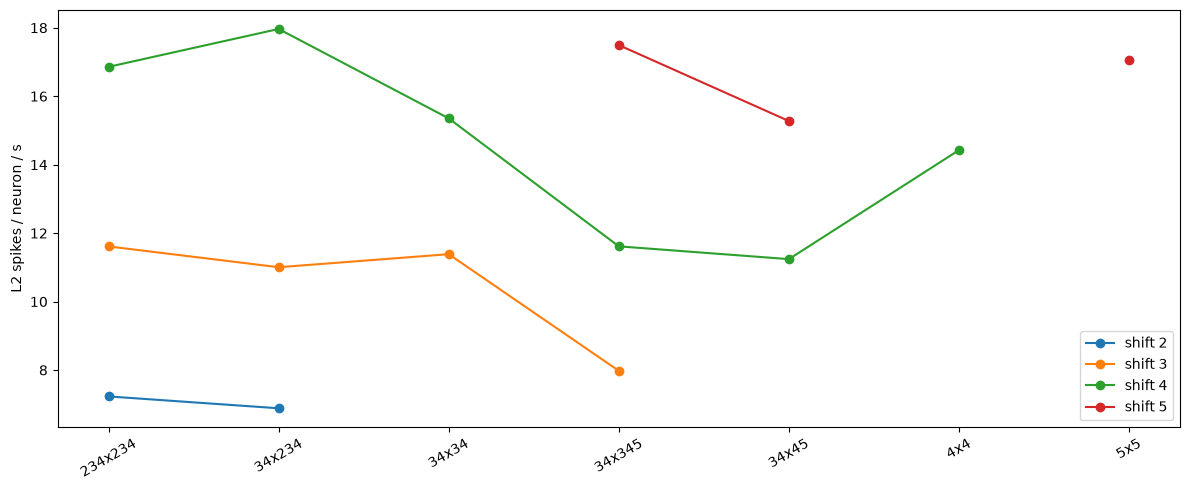

In [7]:
part=dynamics[(dynamics.training_family=='e2e_wc')&(dynamics.regularization=='task_only')&(dynamics.layer=='L2')]
fig,ax=plt.subplots(figsize=(12,5))
for shift in sorted(part['shift'].dropna().unique()):
    vals=[]
    for arch in ARCH_ORDER:
        row=part[(part.architecture==arch)&(part['shift']==shift)]
        vals.append(np.nan if row.empty else row.iloc[0].valid_spikes_per_neuron_second_mean)
    ax.plot(ARCH_ORDER,vals,marker='o',label=f'shift {int(shift)}')
ax.set_ylabel('L2 spikes / neuron / s'); ax.tick_params(axis='x',rotation=30); ax.legend(); fig.tight_layout();

## Regularizer calibration summary
Calibration is architecture- and training-family-specific because WholeCount and timestep CE produce different task gradients.

In [8]:
calibration

,architecture,training_family,regularization,n,lambda_rate_mean,lambda_persist_mean,achieved_rate_grad_ratio_mean,achieved_persist_grad_ratio_mean,lambda_rate_std,lambda_persist_std,achieved_rate_grad_ratio_std,achieved_persist_grad_ratio_std
0,234x234,e2e_wc,task_only,3,0.000000,0.000000,0.000,0.00,0.000000,0.000000,0.000000e+00,0.000000e+00
1,234x234,e2e_wc,task_plus_reg,3,0.040486,0.014492,0.025,0.05,0.016713,0.006476,0.000000e+00,0.000000e+00
2,234x234,local_tsce,task_only,3,0.000000,0.000000,0.000,0.00,0.000000,0.000000,0.000000e+00,0.000000e+00
3,234x234,local_tsce,task_plus_reg,3,0.073561,0.025928,0.025,0.05,0.008262,0.005399,2.453269e-18,0.000000e+00
4,34x234,e2e_wc,task_only,3,0.000000,0.000000,0.000,0.00,0.000000,0.000000,0.000000e+00,0.000000e+00
5,34x234,e2e_wc,task_plus_reg,3,0.034493,0.012460,0.025,0.05,0.010515,0.004945,0.000000e+00,0.000000e+00
6,34x234,local_tsce,task_only,3,0.000000,0.000000,0.000,0.00,0.000000,0.000000,0.000000e+00,0.000000e+00
7,34x234,local_tsce,task_plus_reg,3,0.072311,0.024946,0.025,0.05,0.005619,0.003781,0.000000e+00,0.000000e+00
8,34x34,e2e_wc,task_only,3,0.000000,0.000000,0.000,0.00,0.000000,0.000000,0.000000e+00,0.000000e+00
9,34x34,e2e_wc,task_plus_reg,3,0.044698,0.015776,0.025,0.05,0.011201,0.005099,0.000000e+00,0.000000e+00


## Interpretation checklist

- Main controlled path: `34x34 → 34x345 → 34x45` with L1 fixed at `(3,4)`.
- L2 probe high but E2E WholeCount low: hidden representation survives; streaming readout is the bottleneck.
- Pre-output probe high but post-output probe low: output LIF spike conversion is a bottleneck.
- E2E L2 probe lower than local L2+Linear: WholeCount end-to-end optimization damaged hidden representation.
- Regularization lowers persistence and restores BA: sustained firing is a causal contributor.
- Persistence falls without BA recovery: long τ likely also harms local information through temporal smoothing/mixing.